# 04 · 실시간 복수 물체 탐지·측정 (웹캠)

ChArUco 보드 위의 **여러 물체**를 실시간으로 탐지하고, 각각의 **중심 위치 · 바닥 치수 · 높이**를 화면에 표시한다. ML/딥러닝 없이 고전 필터만 사용.

**방법:** 보드(흑백)는 채도가 낮고 색 있는 물체는 채도가 높다 → 보드영역에 닿은 **채도 덩어리**를 전부 잡아 각각을 물체로 본다(색 종류 무관). 각 물체는 바닥 접점을 보드평면에 역투영해 위치·치수를, 수직 방향으로 높이를 구한다.

**전제:** `01`로 `output/camera_intrinsics.npz` 완료. **웹캠 해상도를 캘리브레이션과 동일(기본 1920×1080)** 하게 맞춰야 정확하다.

**한계(솔직):** 단일 시점·실시간이라 근사다. 중심 위치는 견고, 높이·바닥치수는 근사(색으로 흰색 밑동을 못 잡으면 그만큼 위에서 잼). 흰/회색 무채색 물체는 이 채도 방식으론 안 잡힌다.

In [1]:
import os, sys
import cv2
import numpy as np
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(ROOT, 'src'))
import aruco_utils as au
import live_measure as lm
print('OpenCV', cv2.__version__)

OUTPUT_DIR = os.path.join(ROOT, 'output')
SCENE_DIR = os.path.join(ROOT, 'data', 'scene_images')

# ===== 설정 =====
SQUARES_X, SQUARES_Y = 5, 7
SQUARE_LENGTH_M = 0.038
MARKER_LENGTH_M = 0.038 * 22 / 30
ARUCO_DICT = cv2.aruco.DICT_5X5_1000

CAM_INDEX = 0            # 웹캠 번호 (여러 개면 1,2.. 시도)
CALIB_WH = (1920, 1080)  # 캘리브레이션 해상도 (웹캠도 이걸로 맞춤)
SAT_THRESH = 120         # 물체 채도 임계 (덜 잡히면 낮추고, 보드가 섞이면 높임)
VAL_THRESH = 110
MIN_AREA = 800           # 이보다 작은 덩어리는 무시(노이즈)

# 로드
K, dist = au.load_intrinsics(os.path.join(OUTPUT_DIR, 'camera_intrinsics.npz'))
dictionary = cv2.aruco.getPredefinedDictionary(ARUCO_DICT)
board = cv2.aruco.CharucoBoard((SQUARES_X, SQUARES_Y), SQUARE_LENGTH_M, MARKER_LENGTH_M, dictionary)
print('K loaded, board ready')

OpenCV 4.13.0
K loaded, board ready


## 먼저 정지영상으로 점검 (웹캠 없이 로직 확인)

`data/scene_images/`의 사진으로 탐지·측정 결과를 인라인으로 본다. 여러 물체를 올린 사진을 넣으면 다 잡히는지 확인 가능.

board_found True | objects 1
  #0 pos(116,159)mm size 21x12x63mm


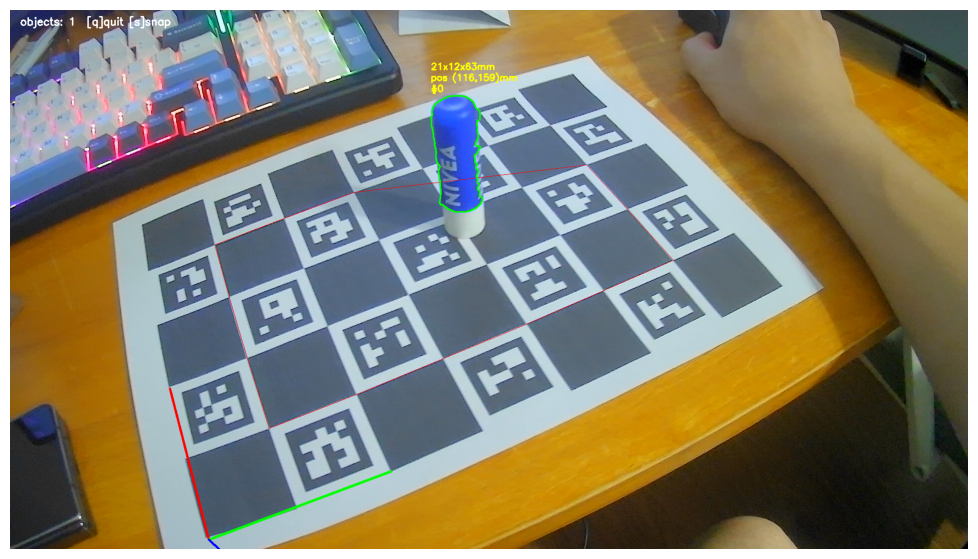

In [2]:
import glob
files = []
for e in ('*.jpg','*.jpeg','*.png','*.JPG','*.PNG'):
    files.extend(glob.glob(os.path.join(SCENE_DIR, e)))
img = cv2.imread(sorted(set(files))[0])
res = lm.measure_objects(img, board, K, dist,
                         sat_thresh=SAT_THRESH, val_thresh=VAL_THRESH, min_area=MIN_AREA)
print('board_found', res['board_found'], '| objects', len(res['objects']))
for i, o in enumerate(res['objects']):
    print(f"  #{i} pos({o['center_mm'][0]:.0f},{o['center_mm'][1]:.0f})mm "
          f"size {o['footprint_mm'][0]:.0f}x{o['footprint_mm'][1]:.0f}x{o['height_mm']:.0f}mm")
vis = lm.draw_overlay(img, res, K, dist, square_len=SQUARE_LENGTH_M)
plt.figure(figsize=(13, 7)); plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.show()

## 실시간 실행 (웹캠)

아래 셀을 실행하면 **별도 창**이 뜬다. 보드 위에 색 있는 물체 여러 개를 놓아보자.
- **`q`**: 종료  
- **`s`**: 현재 화면 스냅샷 저장(`output/`)

> 창이 안 뜨거나 멈추면: `CAM_INDEX` 바꿔보기, 다른 앱이 웹캠 점유 중인지 확인. 로컬(내 PC)에서 실행해야 창이 뜬다(원격/헤드리스 불가).

In [3]:
lm.run_live(K, dist, board,
            cam_index=CAM_INDEX, calib_wh=CALIB_WH, snapshot_dir=OUTPUT_DIR,
            sat_thresh=SAT_THRESH, val_thresh=VAL_THRESH, min_area=MIN_AREA)
print('종료됨')

saved d:\vision algorithm\output\snap_000.png
종료됨


## 튜닝 & 다음

- **물체가 안 잡힘**: `SAT_THRESH` 낮추기 / 물체를 보드 안쪽·중앙에.
- **보드칸·잡음이 물체로 잡힘**: `SAT_THRESH` 높이기 / `MIN_AREA` 키우기.
- **여러 물체가 붙어서 하나로**: 서로 떨어뜨려 놓기 (연결요소 기반이라 붙으면 합쳐짐 → 나중에 watershed로 분리 확장 가능).
- **정확도**: 웹캠 해상도가 `CALIB_WH`와 같은지, 초점·조명 확인. 중심 위치가 실제와 맞는지 자로 검증.
- 다음: 물체 ID/메타정보 매핑, 흰색 물체용 known-background(보드 흑백) 차분, 프레임 안정화(칼만/이동평균), 가상 3D 씬에 실시간 반영(놓으면 생기고 치우면 사라짐).